In [1]:
!pip install scanpy
!pip install magic-impute

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.6/168.6 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 85.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.1/254.1 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.7/53.7 kB 2.4 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.7.2
    Uninstalling matplotlib-3.7.2:
      Successfully uninstalled matplotlib-3.7.2
  Attempting uninstall: seaborn
    Found existing installation: seaborn 0.12.2
    Uninstalling seaborn-0.12.2:
      Successfully uninstalled seaborn-0.12.2
ERROR: pip's dependency resolver does not cur

# Raw Clusters 

Original gene expression shape: (22650, 3919)


adata.X seems to be already log-transformed.
/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
2025-07-22 17:36:57.267961: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753205817.540343      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753205817.616363      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
... storing 'kmeans' as categorical


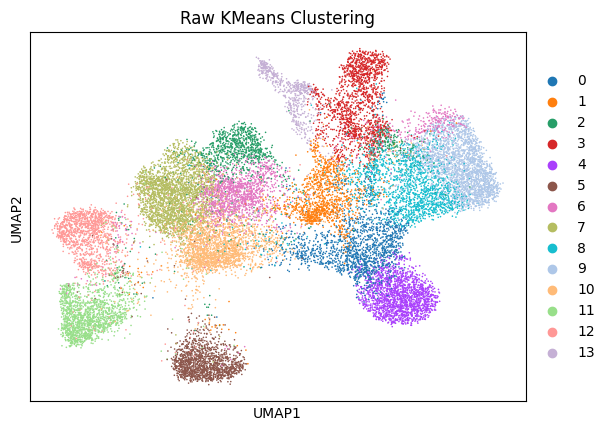

ARI (Adjusted Rand Index) on raw data (KMeans): 0.1740
Percentage of 0s in raw gene expression: 95.78%


In [2]:
import scanpy as sc
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans

# ========== Step 1: Load Data ==========
adata = sc.read_h5ad("/kaggle/input/slide-seq/stickles_mouse_slideseq_processed.h5ad")

# Backup raw data
adata.raw = adata

# Gene Expression & Coordinates
X = adata.X.toarray() if not isinstance(adata.X, np.ndarray) else adata.X
coords = adata.obsm['spatial']
print("Original gene expression shape:", X.shape)
# ========== Step 2: KMeans Clustering on Raw ==========
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.pca(adata)

# Perform KMeans on PCA representation
X_pca = adata.obsm["X_pca"]
kmeans = KMeans(n_clusters=14, random_state=42)
adata.obs["kmeans"] = kmeans.fit_predict(X_pca).astype(str)

# UMAP for visualization
sc.pp.neighbors(adata, use_rep="X_pca")
sc.tl.umap(adata)

# Plot Clustering
sc.pl.umap(adata, color="kmeans", title="Raw KMeans Clustering")
# Evaluate with ARI if ground truth exists
if "annotation" in adata.obs.columns:
    ari = adjusted_rand_score(adata.obs["annotation"], adata.obs["kmeans"])
    print(f"ARI (Adjusted Rand Index) on raw data (KMeans): {ari:.4f}")
else:
    print("'annotation' ground truth not found in adata.obs.")
# Zero Percentage
zero_pct = 100 * (X == 0).sum() / X.size
print(f"Percentage of 0s in raw gene expression: {zero_pct:.2f}%")

# MAGIC Impute K-Means

adata.X seems to be already log-transformed.


Original gene expression shape: (22650, 3919)
Calculating MAGIC...
  Running MAGIC on 22650 cells and 3919 genes.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 5.39 seconds.
    Calculating KNN search...
    Calculated KNN search in 138.75 seconds.
    Calculating affinities...
    Calculated affinities in 132.68 seconds.
  Calculated graph and diffusion operator in 276.86 seconds.
  Calculating imputation...
  Calculated imputation in 11.48 seconds.
Calculated MAGIC in 288.41 seconds.


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
... storing 'kmeans_magic' as categorical


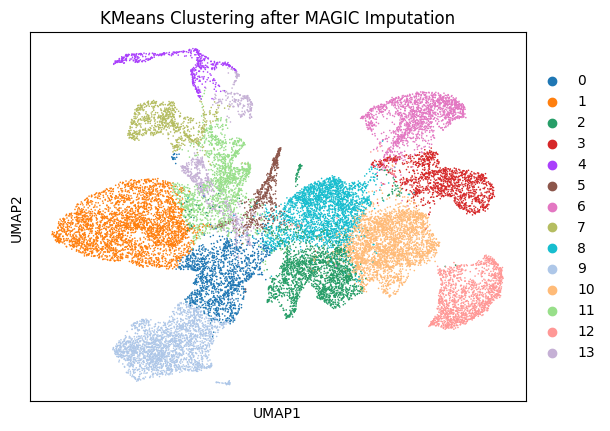

ARI (Adjusted Rand Index) after MAGIC: 0.1764


In [3]:
import scanpy as sc
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans
import magic

# ========== Step 1: Load Data ==========
adata = sc.read_h5ad("/kaggle/input/slide-seq/stickles_mouse_slideseq_processed.h5ad")

# Backup raw data
adata.raw = adata

# Gene Expression & Coordinates
X = adata.X.toarray() if not isinstance(adata.X, np.ndarray) else adata.X
coords = adata.obsm['spatial']
print("Original gene expression shape:", X.shape)

# ========== Step 2: Apply MAGIC Imputation ==========
# Normalize and log-transform before MAGIC
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

# Run MAGIC on raw expression
magic_op = magic.MAGIC()
X_magic = magic_op.fit_transform(X)

# Add MAGIC-imputed data to AnnData object
adata.layers["magic"] = X_magic
adata.X = X_magic  

# ========== Step 3: PCA, KMeans, UMAP ==========
sc.pp.pca(adata)
X_pca = adata.obsm["X_pca"]
# KMeans clustering
kmeans = KMeans(n_clusters=14, random_state=42)
adata.obs["kmeans_magic"] = kmeans.fit_predict(X_pca).astype(str)

# Neighborhood graph and UMAP
sc.pp.neighbors(adata, use_rep="X_pca")
sc.tl.umap(adata)

# Plot
sc.pl.umap(adata, color="kmeans_magic", title="KMeans Clustering after MAGIC Imputation")

# ========== Step 4: Evaluation ==========
if "annotation" in adata.obs.columns:
    ari = adjusted_rand_score(adata.obs["annotation"], adata.obs["kmeans_magic"])
    print(f"ARI (Adjusted Rand Index) after MAGIC: {ari:.4f}")
else:
    print("'annotation' ground truth not found in adata.obs.")


# Attention Algorithm

In [4]:
import scanpy as sc
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from torch.utils.data import DataLoader, TensorDataset

# ========= Load and Prepare =========
adata = sc.read_h5ad("/kaggle/input/slide-seq/stickles_mouse_slideseq_processed.h5ad")
adata.raw = adata
X = adata.X.toarray() if not isinstance(adata.X, np.ndarray) else adata.X
coords = adata.obsm['spatial']

if "annotation" not in adata.obs.columns:
    raise ValueError("No ground truth label 'annotation' found!")

# Limit to top 3000 genes for memory
sc.pp.highly_variable_genes(adata, n_top_genes=3000)
adata = adata[:, adata.var.highly_variable]

X = adata.X.toarray() if not isinstance(adata.X, np.ndarray) else adata.X
coords = adata.obsm['spatial']

# ========== Torch Setup ==========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_tensor = torch.tensor(X, dtype=torch.float32, device=device)
coords_tensor = torch.tensor(coords, dtype=torch.float32, device=device)

# ========== Attention Module ==========
class AdvancedSpatialAttention(nn.Module):
    def __init__(self, input_dim=2, embed_dim=32, heads=2):
        super().__init__()
        self.embedding = nn.Linear(input_dim, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=heads, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=1)

    def forward(self, coords):
        x = self.embedding(coords)
        x = x.unsqueeze(0)
        return self.encoder(x).squeeze(0)

# ========== Imputer ==========
class FusionImputer(nn.Module):
    def __init__(self, gene_dim, spatial_dim):
        super().__init__()
        fused_dim = gene_dim + spatial_dim
        self.encoder = nn.Sequential(
            nn.Linear(fused_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, gene_dim),
            nn.ReLU()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

# ========== Initialize ==========
attn = AdvancedSpatialAttention(embed_dim=32).to(device)
projector = nn.Linear(32, X_tensor.shape[1]).to(device)
model = FusionImputer(gene_dim=X_tensor.shape[1], spatial_dim=X_tensor.shape[1]).to(device)
optimizer = torch.optim.Adam(list(attn.parameters()) + list(projector.parameters()) + list(model.parameters()), lr=1e-3)
loss_fn = nn.MSELoss()

# ========== Precompute Attention Features ==========
attn.eval()
with torch.no_grad():
    spatial_feat = attn(coords_tensor)
    spatial_proj = projector(spatial_feat)

# ========== Prepare Dataloader ==========
batch_size = 256
fused_data = torch.cat([X_tensor, spatial_proj], dim=1)
dataset = TensorDataset(fused_data, X_tensor)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
# ========== Training Loop ==========
model.train()
for epoch in range(50):
    total_loss = 0
    for batch_x, batch_target in loader:
        # Simulate dropout
        mask = (torch.rand_like(batch_target) > 0.2).float()
        batch_dropout = batch_target * mask

        # Fused dropout input
        fused_dropout = torch.cat([batch_dropout, spatial_proj[:batch_x.size(0)]], dim=1)

        # Forward + Backward
        optimizer.zero_grad()
        out = model(fused_dropout)
        loss = loss_fn(out, batch_target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)

    avg_loss = total_loss / len(dataset)
    print(f"Epoch {epoch}: Avg Loss = {avg_loss:.4f}")

# ========== Inference ==========
model.eval()
with torch.no_grad():
    full_fused = torch.cat([X_tensor, spatial_proj], dim=1)
    imputed = model(full_fused).cpu().numpy()



Epoch 0: Avg Loss = 0.0050
Epoch 1: Avg Loss = 0.0047
Epoch 2: Avg Loss = 0.0046
Epoch 3: Avg Loss = 0.0046
Epoch 4: Avg Loss = 0.0045
Epoch 5: Avg Loss = 0.0045
Epoch 6: Avg Loss = 0.0045
Epoch 7: Avg Loss = 0.0045
Epoch 8: Avg Loss = 0.0045
Epoch 9: Avg Loss = 0.0044
Epoch 10: Avg Loss = 0.0044
Epoch 11: Avg Loss = 0.0044
Epoch 12: Avg Loss = 0.0044
Epoch 13: Avg Loss = 0.0044
Epoch 14: Avg Loss = 0.0044
Epoch 15: Avg Loss = 0.0044
Epoch 16: Avg Loss = 0.0044
Epoch 17: Avg Loss = 0.0044
Epoch 18: Avg Loss = 0.0044
Epoch 19: Avg Loss = 0.0044
Epoch 20: Avg Loss = 0.0043
Epoch 21: Avg Loss = 0.0043
Epoch 22: Avg Loss = 0.0043
Epoch 23: Avg Loss = 0.0043
Epoch 24: Avg Loss = 0.0043
Epoch 25: Avg Loss = 0.0043
Epoch 26: Avg Loss = 0.0043
Epoch 27: Avg Loss = 0.0043
Epoch 28: Avg Loss = 0.0043
Epoch 29: Avg Loss = 0.0043
Epoch 30: Avg Loss = 0.0043
Epoch 31: Avg Loss = 0.0043
Epoch 32: Avg Loss = 0.0043
Epoch 33: Avg Loss = 0.0043
Epoch 34: Avg Loss = 0.0043
Epoch 35: Avg Loss = 0.0043
Ep

# Attention + PCA

/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:618: FutureWarning: You are attempting to set `X` to a matrix on a view which has non-unique indices. The resulting `adata.X` will likely not equal the value to which you set it. To avoid this potential issue, please make a copy of the data first. In the future, this operation will throw an error.
  warnings.warn(msg, FutureWarning, stacklevel=1)
/tmp/ipykernel_13/1078344600.py:1: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  adata.X = imputed
/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:201: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray_sparse(i, j, x)
/usr/local/lib/python3.11/dist-packages/scanpy/preprocessing/_pca/__init__.py:383: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
/usr

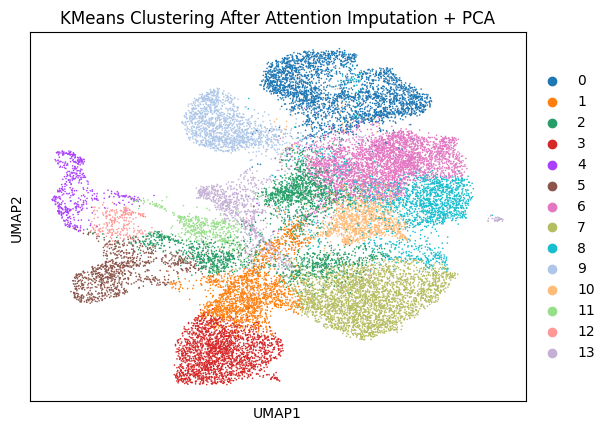

🎯 ARI after Imputation (KMeans): 0.2249
🧊 Zero % after Imputation: 78.28%


In [5]:
adata.X = imputed

# ----- PCA -----
sc.pp.pca(adata, n_comps=50)
pca_result = adata.obsm["X_pca"]

# ----- KMeans Clustering -----
kmeans = KMeans(n_clusters=14, random_state=42)
adata.obs["kmeans"] = kmeans.fit_predict(pca_result).astype(str)

# ----- UMAP for Visualization -----
sc.pp.neighbors(adata, use_rep="X_pca")
sc.tl.umap(adata)
sc.pl.umap(adata, color="kmeans", title="KMeans Clustering After Attention Imputation + PCA")

# ----- Evaluation -----
ari = adjusted_rand_score(adata.obs["annotation"], adata.obs["kmeans"])
print(f"🎯 ARI after Imputation (KMeans): {ari:.4f}")

zero_pct = 100 * (imputed == 0).sum() / imputed.size
print(f"🧊 Zero % after Imputation: {zero_pct:.2f}%")

# Attention + UMAP

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
... storing 'kmeans' as categorical


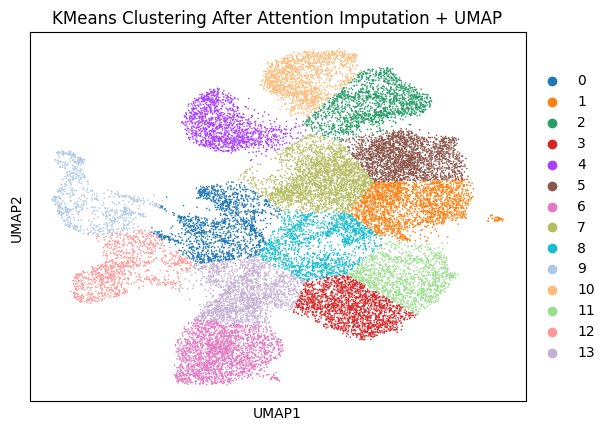

🎯 ARI after Imputation (KMeans on UMAP): 0.1736
🧊 Zero % after Imputation: 78.28%


In [6]:
import scanpy as sc
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# Replace the expression matrix with imputed values
adata.X = imputed

# ----- Compute neighbors and UMAP -----
sc.pp.neighbors(adata)
sc.tl.umap(adata)

# Confirm UMAP is computed
if "X_umap" not in adata.obsm:
    raise ValueError("UMAP embedding not found in adata.obsm['X_umap'].")

# ----- KMeans on UMAP coordinates -----
umap_result = adata.obsm["X_umap"]
if not isinstance(umap_result, np.ndarray):
    umap_result = np.array(umap_result)

kmeans = KMeans(n_clusters=14, random_state=42)
adata.obs["kmeans"] = kmeans.fit_predict(umap_result).astype(str)

# ----- Visualization -----
sc.pl.umap(adata, color="kmeans", title="KMeans Clustering After Attention Imputation + UMAP")

# ----- Evaluation -----
if "annotation" in adata.obs.columns:
    ari = adjusted_rand_score(adata.obs["annotation"], adata.obs["kmeans"])
    print(f"🎯 ARI after Imputation (KMeans on UMAP): {ari:.4f}")
else:
    print(" 'annotation' column not found in adata.obs — skipping ARI evaluation.")

zero_pct = 100 * (imputed == 0).sum() / imputed.size
print(f"🧊 Zero % after Imputation: {zero_pct:.2f}%")

# SpatialMAGIC

Applying MAGIC imputation...
Starting MAGIC imputation...
Input data shape: (22650, 3000)
Applying PCA with 100 components...
Building kNN graph with k=5...
Computing affinity matrix...
Normalizing affinity matrix...
Applying diffusion operator with t=3...
MAGIC completed. Output shape: (22650, 3000)
Original data shape: (22650, 3000)
MAGIC imputed data shape: (22650, 3000)
Starting neural network training...
Epoch 0: Avg Loss = 0.0007
Epoch 1: Avg Loss = 0.0003
Epoch 2: Avg Loss = 0.0003
Epoch 3: Avg Loss = 0.0002
Epoch 4: Avg Loss = 0.0002
Epoch 5: Avg Loss = 0.0002
Epoch 6: Avg Loss = 0.0002
Epoch 7: Avg Loss = 0.0002
Epoch 8: Avg Loss = 0.0001
Epoch 9: Avg Loss = 0.0001
Epoch 10: Avg Loss = 0.0001
Epoch 11: Avg Loss = 0.0001
Epoch 12: Avg Loss = 0.0001
Epoch 13: Avg Loss = 0.0001
Epoch 14: Avg Loss = 0.0002
Epoch 15: Avg Loss = 0.0001
Epoch 16: Avg Loss = 0.0001
Epoch 17: Avg Loss = 0.0001
Epoch 18: Avg Loss = 0.0001
Epoch 19: Avg Loss = 0.0001
Epoch 20: Avg Loss = 0.0001
Epoch 21:

/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:618: FutureWarning: You are attempting to set `X` to a matrix on a view which has non-unique indices. The resulting `adata.X` will likely not equal the value to which you set it. To avoid this potential issue, please make a copy of the data first. In the future, this operation will throw an error.
  warnings.warn(msg, FutureWarning, stacklevel=1)
/tmp/ipykernel_13/3208333562.py:324: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  adata.X = final_imputed
/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:201: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray_sparse(i, j, x)
/usr/local/lib/python3.11/dist-packages/scanpy/preprocessing/_pca/__init__.py:383: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_

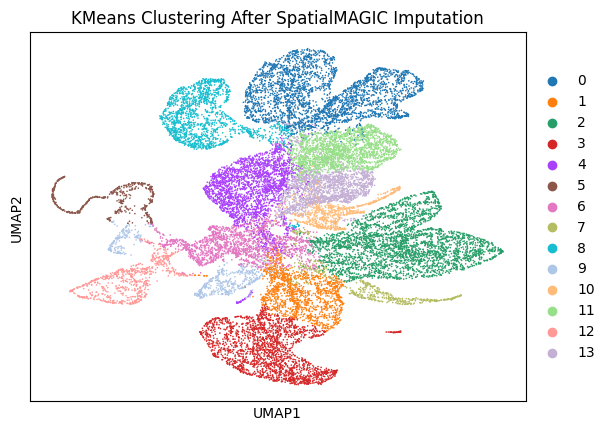

🎯 ARI after Imputation (KMeans): 0.2193
🧊 Zero % after Imputation: 68.06%


In [7]:
import scanpy as sc
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import pairwise_distances
from scipy.sparse import csr_matrix
from torch.utils.data import DataLoader, TensorDataset

# ========= MAGIC Imputation Implementation =========
class MAGICImputer:
    def __init__(self, knn=5, knn_max=None, decay=1, t=3, npca=100, 
                 knn_dist_method='euclidean', verbose=1):
        """
        MAGIC (Markov Affinity-based Graph Imputation of Cells) implementation
        
        Parameters:
        -----------
        knn : int, default=5
            Number of nearest neighbors
        knn_max : int, optional
            Maximum number of neighbors (default: 3*knn)
        decay : float, default=1
            Decay rate of kernel tails
        t : int, default=3
            Power of diffusion operator
        npca : int, default=100
            Number of PCA components
        knn_dist_method : str, default='euclidean'
            Distance method for kNN graph
        verbose : int, default=1
            Verbosity level
        """
        self.knn = knn
        self.knn_max = knn_max if knn_max is not None else 3 * knn
        self.decay = decay
        self.t = t
        self.npca = npca
        self.knn_dist_method = knn_dist_method
        self.verbose = verbose
        self.is_fitted = False
        
    def _pca_transform(self, X):
        """Apply PCA transformation"""
        if self.verbose:
            print(f"Applying PCA with {self.npca} components...")
        
        pca = PCA(n_components=min(self.npca, X.shape[1], X.shape[0]))
        X_pca = pca.fit_transform(X)
        self.pca_ = pca
        return X_pca
    
    def _build_knn_graph(self, X):
        """Build k-nearest neighbors graph"""
        if self.verbose:
            print(f"Building kNN graph with k={self.knn}...")
            
        # Use sklearn's NearestNeighbors for efficiency
        nbrs = NearestNeighbors(n_neighbors=min(self.knn_max, X.shape[0]), 
                               metric=self.knn_dist_method)
        nbrs.fit(X)
        
        # Get distances and indices
        distances, indices = nbrs.kneighbors(X)
        
        return distances, indices
    
    def _compute_affinity_matrix(self, distances, indices):
        """Compute affinity matrix from distances"""
        if self.verbose:
            print("Computing affinity matrix...")
            
        n_samples = len(indices)
        
        # Initialize affinity matrix
        W = np.zeros((n_samples, n_samples))
        
        for i in range(n_samples):
            # Compute adaptive bandwidth (median distance to knn neighbors)
            knn_distances = distances[i][:self.knn]
            bandwidth = np.median(knn_distances)
            
            # Compute affinities for all neighbors
            neighbor_indices = indices[i]
            neighbor_distances = distances[i]
            
            # Apply Gaussian kernel with adaptive bandwidth
            if bandwidth > 0:
                affinities = np.exp(-(neighbor_distances**2) / (2 * bandwidth**2))
                
                # Apply decay if specified
                if self.decay is not None and self.decay != 1:
                    affinities = affinities ** self.decay
                
                # Set affinities in matrix
                W[i, neighbor_indices] = affinities
        
        # Make symmetric
        W = (W + W.T) / 2
        
        return W
    
    def _normalize_affinity_matrix(self, W):
        """Normalize affinity matrix to create transition matrix"""
        if self.verbose:
            print("Normalizing affinity matrix...")
            
        # Row-normalize to create transition matrix
        row_sums = np.array(W.sum(axis=1)).flatten()
        row_sums[row_sums == 0] = 1  # Avoid division by zero
        
        D_inv = np.diag(1.0 / row_sums)
        P = D_inv @ W
        
        return P
    
    def _diffuse(self, P, X):
        """Apply diffusion operator"""
        if self.verbose:
            print(f"Applying diffusion operator with t={self.t}...")
            
        # Power iteration: P^t
        P_t = P.copy()
        for _ in range(self.t - 1):
            P_t = P_t @ P
        
        # Apply to data
        X_diffused = P_t @ X
        
        return X_diffused
    
    def fit_transform(self, X, genes=None):
        """
        Fit MAGIC and transform data
        
        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
            Input data matrix
        genes : array-like, optional
            Subset of genes to return (indices or names)
            
        Returns:
        --------
        X_magic : array-like
            Imputed data matrix
        """
        if self.verbose:
            print("Starting MAGIC imputation...")
            print(f"Input data shape: {X.shape}")
        
        # Store original data
        self.X_original_ = X.copy()
        
        # Step 1: PCA preprocessing
        if self.npca is not None and self.npca < X.shape[1]:
            X_pca = self._pca_transform(X)
        else:
            X_pca = X.copy()
        
        # Step 2: Build kNN graph
        distances, indices = self._build_knn_graph(X_pca)
        
        # Step 3: Compute affinity matrix
        W = self._compute_affinity_matrix(distances, indices)
        
        # Step 4: Normalize to transition matrix
        P = self._normalize_affinity_matrix(W)
        
        # Step 5: Apply diffusion
        X_diffused = self._diffuse(P, X)  # Apply to original data, not PCA
        
        # Store results
        self.transition_matrix_ = P
        self.is_fitted = True
        
        # Handle gene selection
        if genes is not None:
            if isinstance(genes, (list, np.ndarray)):
                if isinstance(genes[0], str):
                    # Assume genes are column names - would need column mapping
                    X_result = X_diffused
                else:
                    # Assume genes are indices
                    X_result = X_diffused[:, genes]
            else:
                X_result = X_diffused
        else:
            X_result = X_diffused
        
        if self.verbose:
            print(f"MAGIC completed. Output shape: {X_result.shape}")
        
        return X_result

# ========= Load and Prepare =========
adata = sc.read_h5ad("/kaggle/input/slide-seq/stickles_mouse_slideseq_processed.h5ad")
adata.raw = adata
X = adata.X.toarray() if not isinstance(adata.X, np.ndarray) else adata.X
coords = adata.obsm['spatial']

if "annotation" not in adata.obs.columns:
    raise ValueError("No ground truth label 'annotation' found!")

# Limit to top 3000 genes for memory
sc.pp.highly_variable_genes(adata, n_top_genes=3000)
adata = adata[:, adata.var.highly_variable]
X = adata.X.toarray() if not isinstance(adata.X, np.ndarray) else adata.X
coords = adata.obsm['spatial']

# ========== Apply MAGIC Imputation ==========
print("Applying MAGIC imputation...")
magic_imputer = MAGICImputer(
    knn=5,           # Number of nearest neighbors
    knn_max=15,      # Maximum neighbors (3*knn)
    decay=1,         # Decay rate
    t=3,             # Diffusion steps
    npca=100,        # PCA components
    knn_dist_method='euclidean',
    verbose=1
)

# Apply MAGIC imputation
X_magic = magic_imputer.fit_transform(X)
print(f"Original data shape: {X.shape}")
print(f"MAGIC imputed data shape: {X_magic.shape}")

# ========== Torch Setup ==========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Use MAGIC imputed data instead of original
X_tensor = torch.tensor(X_magic, dtype=torch.float32, device=device)
coords_tensor = torch.tensor(coords, dtype=torch.float32, device=device)

# ========== Attention Module ==========
class AdvancedSpatialAttention(nn.Module):
    def __init__(self, input_dim=2, embed_dim=32, heads=2):
        super().__init__()
        self.embedding = nn.Linear(input_dim, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=heads, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=1)
    
    def forward(self, coords):
        x = self.embedding(coords)
        x = x.unsqueeze(0)
        return self.encoder(x).squeeze(0)

# ========== Imputer ==========
class FusionImputer(nn.Module):
    def __init__(self, gene_dim, spatial_dim):
        super().__init__()
        fused_dim = gene_dim + spatial_dim
        self.encoder = nn.Sequential(
            nn.Linear(fused_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, gene_dim),
            nn.ReLU()
        )
    
    def forward(self, x):
        return self.decoder(self.encoder(x))

# ========== Initialize ==========
attn = AdvancedSpatialAttention(embed_dim=32).to(device)
projector = nn.Linear(32, X_tensor.shape[1]).to(device)
model = FusionImputer(gene_dim=X_tensor.shape[1], spatial_dim=X_tensor.shape[1]).to(device)
optimizer = torch.optim.Adam(list(attn.parameters()) + list(projector.parameters()) + list(model.parameters()), lr=1e-3)
loss_fn = nn.MSELoss()

# ========== Precompute Attention Features ==========
attn.eval()
with torch.no_grad():
    spatial_feat = attn(coords_tensor)
    spatial_proj = projector(spatial_feat)

# ========== Prepare Dataloader ==========
batch_size = 256
fused_data = torch.cat([X_tensor, spatial_proj], dim=1)
dataset = TensorDataset(fused_data, X_tensor)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# ========== Training Loop ==========
print("Starting neural network training...")
model.train()
for epoch in range(50):
    total_loss = 0
    for batch_x, batch_target in loader:
        # Simulate dropout
        mask = (torch.rand_like(batch_target) > 0.2).float()
        batch_dropout = batch_target * mask
        
        # Fused dropout input
        fused_dropout = torch.cat([batch_dropout, spatial_proj[:batch_x.size(0)]], dim=1)
        
        # Forward + Backward
        optimizer.zero_grad()
        out = model(fused_dropout)
        loss = loss_fn(out, batch_target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch_x.size(0)
    
    avg_loss = total_loss / len(dataset)
    print(f"Epoch {epoch}: Avg Loss = {avg_loss:.4f}")

# ========== Inference ==========
model.eval()
with torch.no_grad():
    full_fused = torch.cat([X_tensor, spatial_proj], dim=1)
    final_imputed = model(full_fused).cpu().numpy()

print("Pipeline completed!")
print(f"Final imputed data shape: {final_imputed.shape}")

adata.X = final_imputed

# ----- PCA -----
sc.pp.pca(adata, n_comps=50)
pca_result = adata.obsm["X_pca"]

# ----- KMeans Clustering -----
kmeans = KMeans(n_clusters=14, random_state=42)
adata.obs["kmeans"] = kmeans.fit_predict(pca_result).astype(str)

# ----- UMAP for Visualization -----
sc.pp.neighbors(adata, use_rep="X_pca")
sc.tl.umap(adata)
sc.pl.umap(adata, color="kmeans", title="KMeans Clustering After SpatialMAGIC Imputation")

# ----- Evaluation -----
ari = adjusted_rand_score(adata.obs["annotation"], adata.obs["kmeans"])
print(f"🎯 ARI after Imputation (KMeans): {ari:.4f}")

zero_pct = 100 * (final_imputed == 0).sum() / final_imputed.size
print(f"🧊 Zero % after Imputation: {zero_pct:.2f}%")